# Master Pendulum: Switching and Contact-Aware Modes

This notebook uses the actual `MasterPendulum` class to demonstrate mode selection,
hysteresis, and contact-aware switching.


## Overview

1. Configure a contact-enabled FEM pendulum as the reference model.
2. Instantiate `MasterPendulum` and initialize it.
3. Set a contact-aware `mode_selector` and hysteresis.
4. Simulate and inspect synchronization events.


## Learning Goals

- Understand how to configure the `MasterPendulum` for contact-aware switching.
- Understanding effects of hysteresis and dwell time on mode switching.

## Prerequisites

You should be familiar with the FMU, OpenSim, and FEM pendulum components.
This notebook focuses on switching behavior and does not re-derive the models.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from demos.ControlledPendulum.src.master_pendulum.orchestration.master_pendulum import MasterPendulum
from demos.ControlledPendulum.src.master_pendulum.components.fem import pendulum_config as config
from syssimx.core.multi_comp import Hysteresis

## Configure FEM Parameters

We enable contact so the `MasterPendulum` uses its contact-aware switching logic.
The FEM model acts as the reference for mass/inertia/length synchronization.


In [2]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 20.0
init_params.angular_velocity = 0.0
init_params.drive_torque = 0.0

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11
mat_params.nu_pendulum = 0.3
mat_params.rho_pendulum = 7800

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 0.5
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = True

fem_parameters = {
    "mat_params": mat_params,
    "contact_params": contact_params,
    "init_params": init_params,
    "sim_params": sim_params,
    "anim_params": anim_params,
}


## Instantiate MasterPendulum

Initialization will:
- initialize FEM first,
- synchronize parameters to FMU and OpenSim,
- select the contact-aware mode selector if contact is enabled.


In [3]:
pendulum = MasterPendulum(name="MasterPendulum", initial_mode="FEM")
pendulum.set_parameters(**{"FEM": fem_parameters})
pendulum.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


## Mode Selector and Hysteresis

We are overriding the default mode selector to use contact gap distance for switching.
In this scenario the `MasterPendulum` will switch to FMU mode when the pendulum is far from the wall, in the intermediate gap range it will use the OpenSim model, and when in contact it will use the FEM model.

This kind of mode selector is computationally expensive since it requires for each step to update the internal grid functions of the FEM model to compute the contact gap distance. In practice, you would likely want to use a more efficient switching criterion (e.g. based on the pendulum angle or velocity) and only update the FEM state and compute the gap distance when close to the wall.

If there is no contact, the mode selector will return "FMU".



In [4]:
def contact_mode_selector(t, state):
    if not pendulum._with_contact:
        return "FMU"
    else:
        pendulum.fem.set_state(state, t)
        gap = pendulum.fem._get_contact_gap_distance()
        if gap > 0.15:
            return "FMU"
        elif gap > 0.05:
            return "OpenSim"
        else:
            return "FEM"

pendulum.mode_selector = contact_mode_selector

Additionally, we set a hysteresis dwell time to prevent rapid switching when the pendulum is near the switching thresholds.

In [5]:
dwell_time = 0.05
pendulum.hysteresis = Hysteresis(dwell_time=dwell_time)

## Simulate and Record Synchronization Events

We step the system, log the active mode, and inspect `sync_events` to verify
that switching preserves the shared state.


In [6]:
pendulum.setup_monitoring()
pendulum.display_monitoring()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [8]:
t = 0.0
dt = sim_params.tau
t_end = sim_params.t_end

mode_log = []

while t < t_end:
    pendulum.set_inputs({"tau": 0.0}, t=t)
    pendulum.do_step(t, dt)
    mode_log.append((t, pendulum.active_mode))
    t += dt


[MasterPendulum] Switching: FEM to FMU @ t=0.0500s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
[MasterPendulum] Swit

## Visualize Mode Switching


In [9]:
common_style = {'linestyle': 'None', 'markersize': 3}
fem_style = {**common_style, 'marker': 'o', 'color': 'blue', 'label': 'FEM'}
fmu_style = {**common_style, 'marker': 's', 'color': 'orange', 'label': 'FMU'}
opensim_style = {**common_style, 'marker': 'd', 'color': 'green', 'label': 'OpenSim'}
ref_style = {'linestyle': '--', 'color': 'red', 'label': 'Reference', 'linewidth': 2}
styles = {'FEM': fem_style, 'FMU': fmu_style, 'OpenSim': opensim_style}

In [10]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict["alpha"]
    omega_vals[mode] = res_dict["omega"]
    q_vals[mode] = res_dict["theta"]

histories = {}
for mode in pendulum.models.keys():
    histories[mode] = {
        "time": t_vals[mode],
        "alpha": alpha_vals[mode],
        "omega": omega_vals[mode],
        "q": q_vals[mode],
    }

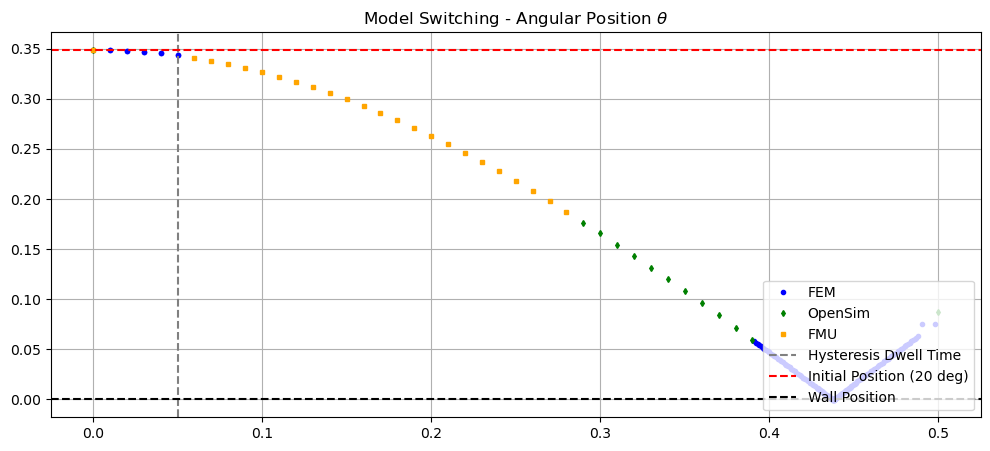

In [11]:
plt.figure(figsize=(12, 5))
plt.title("Model Switching - Angular Position $\\theta$")
for mode, history in histories.items():
    plt.plot(history['time'], history['q'], **styles[mode])
plt.axvline(x=pendulum.hysteresis.dwell_time, color='gray', linestyle='--', label='Hysteresis Dwell Time')
plt.axhline(y=np.deg2rad(20), color='red', linestyle='--', label='Initial Position (20 deg)')
plt.axhline(y=0.0, color='black', linestyle='--', label="Wall Position")
plt.grid()
plt.legend(loc='lower right')
plt.show()